In [9]:
# Ячейка № 1

# вычисление зависимостей смещений
# относительно положения равновесия и
# скоростей движения масс
# колебательной системы от времени

# подключение библиотеки numpy
import numpy as np

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение функций fft, fftfreq
from scipy.fft import fft, fftfreq

In [ ]:
# Ячейка № 2

# задание числа масс
# колебательной системы
N = 4

# задание масс колебательной системы
m = np.array([1, 1, 1, 1])

# задание жесткостей пружин
# колебательной системы
k = np.array([1, 1, 1, 1, 1])

# задание значений смещений масс
# колебательной системы относительно
# их положений равновесия
R0 = np.array([0.1, 0, 0, 0])
# задание начальных скоростей
#  масс колебательной системы
v0 = np.array([0, 0, 0, 0])

# инициализация массива omega,
# используемого для хранения отношений
# жесткостей пружин к массам грузов
omega = np.zeros([N + 1, N])

# инициализация массива Omega,
# используемого для хранения
# квадратов частот, входящих
# в характеристическое уравнение (9.6)
Omega = np.zeros([N, N])

# вычисление отношений
# жесткостей пружин к массам грузов
for i in range(N + 1):
    for j in range(N):
        omega[i, j] = k[i] / m[j]

# вычисление квадратов частот, входящих
# в характеристическое соотношение (9.6)
for i in range(N):
    if i == 0:
        Omega[0, 0] = omega[0, 0] + omega[1, 0]
        Omega[0, 1] = -omega[1, 0]
    if i > 0:
        if i < N - 1:
            Omega[i, i - 1] = -omega[i, i]
            Omega[i, i] = omega[i, i] + omega[i + 1, i]
            Omega[i, i + 1] = -omega[i + 1, i]
        else:
            Omega[i, i - 1] = -omega[i, i]
            Omega[i, i] = omega[i, i] + omega[i + 1, i]

# вычисление собственных чисел и
# собственных векторов матрицы Omеga,
# элементы которой вычисляются
# в соответствие с (9.4)
Teta, Sigma = np.linalg.eig(Omega)

# вывод собственных значений и собственных векторов
# матрицы B в (9.4)
print("Собственные числа матрицы Omega:\n\n", Teta)
print(" ")
print(
    "Соответствующие собственные векторы (в столбцах):\
              \n\n",
    Sigma,
)

print(" ")
# вывод на экран
# значений собственных частот нормальных колебаний
print(
    "Собственные частоты нормальных колебаний: \
                  \n\n",
    np.sqrt(Teta[:]) / (2 * np.pi),
)

# инициализация массива Teta_M,
# используемого для создания
# диагональной матрицы, в которой
# на главной диагонали размещаются с
# соответствующие собственные числа матрицы B
Teta_M = np.zeros([N, N])

# размещение на главной диагонали матрицы Teta_M
# сответствующего собственных чисел матрицы B
for i in range(N):
    Teta_M[i, i] = np.sqrt(Teta[i])

# инициализация матрицы SigmaV
SigmaV = np.zeros([N, N])

# вычисление значений элементов
# матрицы SigmaV в соответствие с (9.15)
for i in range(N):
    for j in range(N):
        SigmaV[i, j] = -Teta_M[i, i] * Sigma[j, i]

# транспонирование матрицы SigmaV
SigmaV = SigmaV.T

# решение системы линейных уравнений (9.18)
C1 = np.linalg.solve(Sigma, R0)

# решение системы линейных уравнений (9.19)
C2 = np.linalg.solve(SigmaV, v0)

# инициализация массива, используемого
# для хранения координат вектора С
C = np.zeros(4)

# вычисление координат вектора С
# в соответствие с (9.20)
for i in range(N):
    C[i] = np.sqrt(C1[i] ** 2 + C2[i] ** 2)

# инициализация массива Alpha,
# используемого для хранения
# начальных фаз нормальных колебаний
Alpha = np.zeros(N)

# вычисление начальных фаз нормальных колебаний
# в соответствие с (9.21), (9.22)
for i in range(N):
    if C[i] == 0:
        Alpha[i] = 0
    else:
        Alpha[i] = np.arctan(C2[i] / C1[i])
        if C1[i] < 0:
            Alpha[i] = np.pi + Alpha[i]
        if C1[i] > 0:
            if C2[i] < 0:
                Alpha[i] = 2 * np.pi + Alpha[i]

# задание числа узлов временной сетки
N1 = 2**15
Tmax = 80
t = np.linspace(0, Tmax, N1)

# инициализация массива X[N,N1],
# используемых для хранения значений координат
# каждой из масс колебательной системы,
# вычисленных в узлах
# выбранной временной сетки
X = np.zeros([N, N1])

# вычисление мгновенных значений зависимостей
# смещений от положения равновесия
# каждой из масс колебательной системы
# в узлах выбранной временной сетки
# в соответствие с (9.10)
for i in range(N1):
    s = np.zeros([N, 1])
    for j in range(N):
        for n in range(N):
            s[j, 0] = s[j, 0] + C[n] * Sigma[j, n] * np.cos(
                Teta_M[n, n] * t[i] + Alpha[n]
            )
        for m0 in range(N):
            X[m0, i] = s[m0, 0]

# инициализация массива Xv[N,N1],
# используемых для хранения
# мгновенных значений скоростей каждой
# из масс колебательной системы,
# вычисляемых в узлах выбранной временной сетки
Xv = np.zeros([N, N1])

# вычисление значений мгновенных значений скоростей
# каждой из масс колебательной системы
# в узлах выбранной временной сетки с (9.11)
for i in range(N1):
    s = np.zeros([N, 1])
    for j in range(N):
        for n in range(N):
            s[j, 0] = s[j, 0] + C[n] * Sigma[j, n] * Teta_M[n, n] * np.sin(
                Teta_M[n, n] * t[i] + Alpha[n]
            )
        for m0 in range(N):
            Xv[m0, i] = -s[m0, 0]

Собственные числа матрицы Omega:

 [3.61803399 2.61803399 0.38196601 1.38196601]
 
Соответствующие собственные векторы (в столбцах):              

 [[-0.37174803 -0.60150096 -0.37174803 -0.60150096]
 [ 0.60150096  0.37174803 -0.60150096 -0.37174803]
 [-0.60150096  0.37174803 -0.60150096  0.37174803]
 [ 0.37174803 -0.60150096 -0.37174803  0.60150096]]
 
Собственные частоты нормальных колебаний:                   

 [0.30273069 0.25751811 0.09836316 0.18709786]


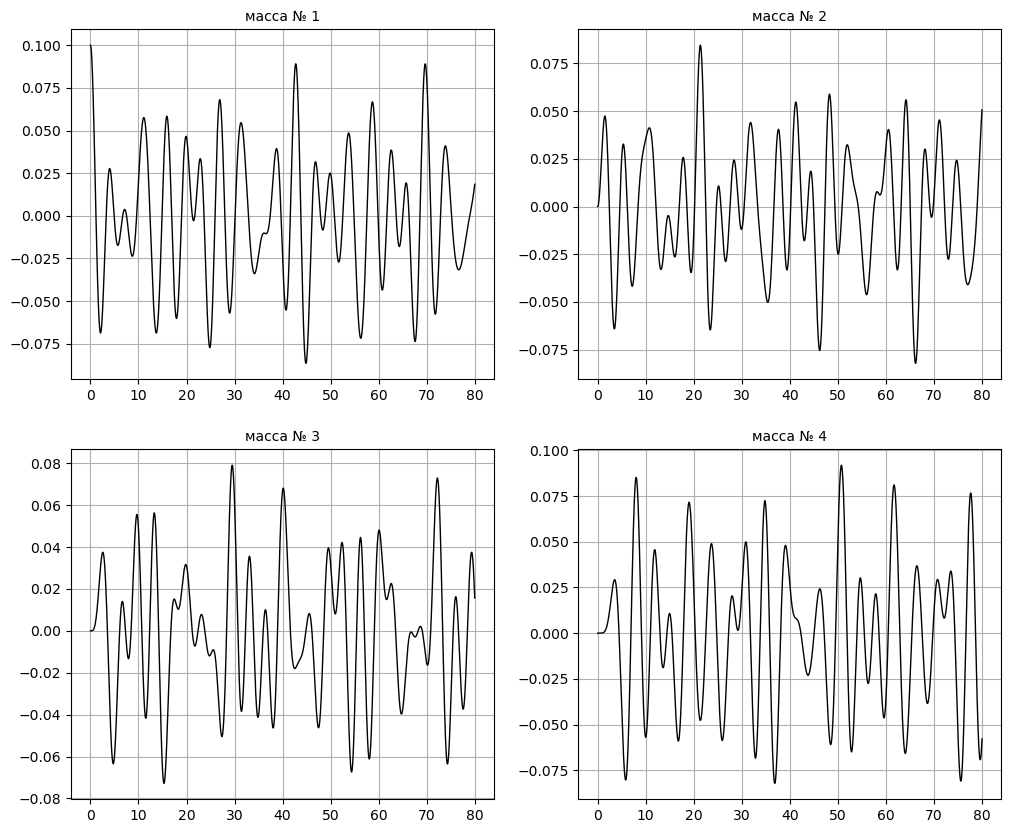

In [11]:
# Ячейка № 3

# визуализация зависимостей смещений
# масс колебательной системы
# от положений от времени


# визуализация зависимостей смещений
# от положения равновесия
# масс колебательной системы от времени
fig = plt.figure(figsize=(12, 10))

# визуализация зависимости смещения
# от положения равновесия
# массы № 1 колебательной системы от времени
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(t[:], X[0, :], "-k", lw=1)
ax1.grid(True)
ax1.set_title("масса № 1", fontsize=10)

# визуализация зависимости смещения
# от положения равновесия
# массы № 2 колебательной системы от времени
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t, X[1, :], "-k", lw=1)
ax2.grid(True)
ax2.set_title("масса № 2", fontsize=10)

# визуализация зависимости смещения
# от положения равновесия
# массы № 3 колебательной системы от времени
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(t, X[2, :], "-k", lw=1)
ax3.grid(True)
ax3.set_title("масса № 3", fontsize=10)


# визуализация зависимости смещения
# от положения равновесия
# массы № 4 колебательной системы от времени
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(t, X[3, :], "-k", lw=1)
ax4.grid(True)
ax4.set_title("масса № 4", fontsize=10)

plt.show()

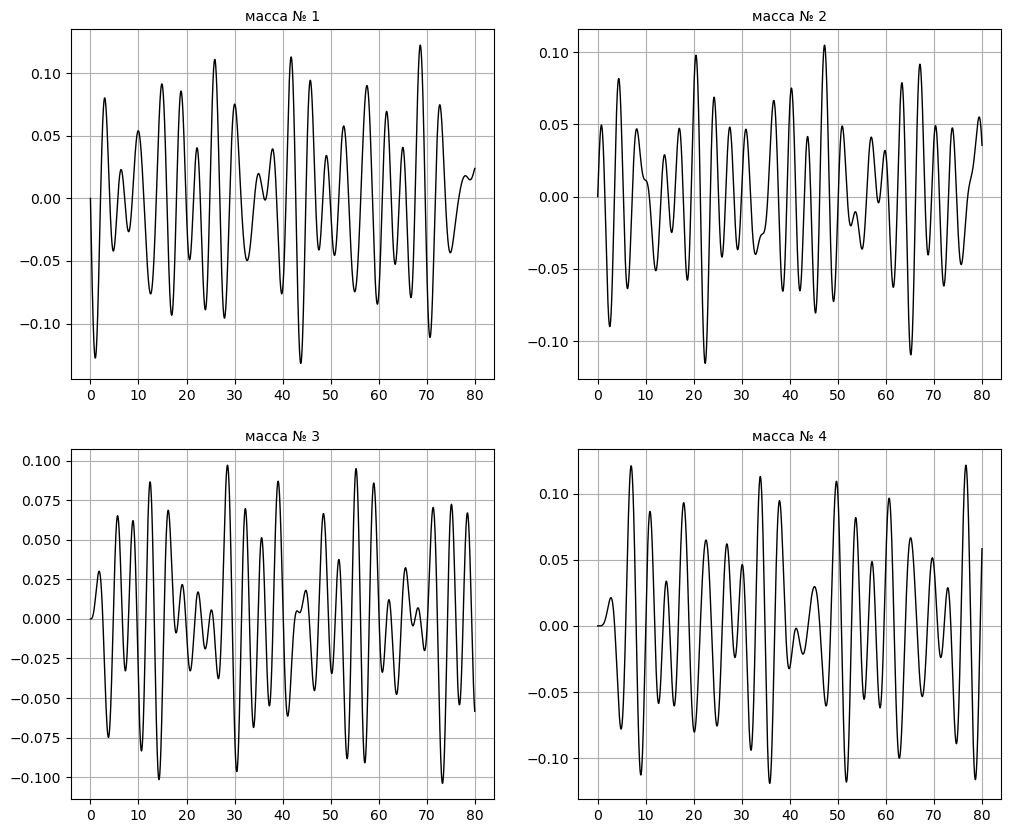

In [12]:
# Ячейка № 4

# визуализация зависимостей скоростей
# масс колебательной системы от времени
fig = plt.figure(figsize=(12, 10))

# визуализация зависимости скорости
# массы № 1 колебательной системы от времени
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(t, Xv[0, :], "-k", lw=1)
ax1.grid(True)
ax1.set_title("масса № 1", fontsize=10)

# визуализация зависимости скорости
# массы № 2 колебательной системы от времени
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t[:], Xv[1, :], "-k", lw=1)
ax2.grid(True)
ax2.set_title("масса № 2", fontsize=10)

# визуализация зависимости скорости
# массы № 3 колебательной системы от времени
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(t[:], Xv[2, :], "-k", lw=1)
ax3.grid(True)
ax3.set_title("масса № 3", fontsize=10)


# визуализация зависимости скорости
# массы № 4 колебательной системы от времени
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(t[:], Xv[3, :], "-k", lw=1)
ax4.grid(True)
ax4.set_title("масса № 4", fontsize=10)

plt.show()

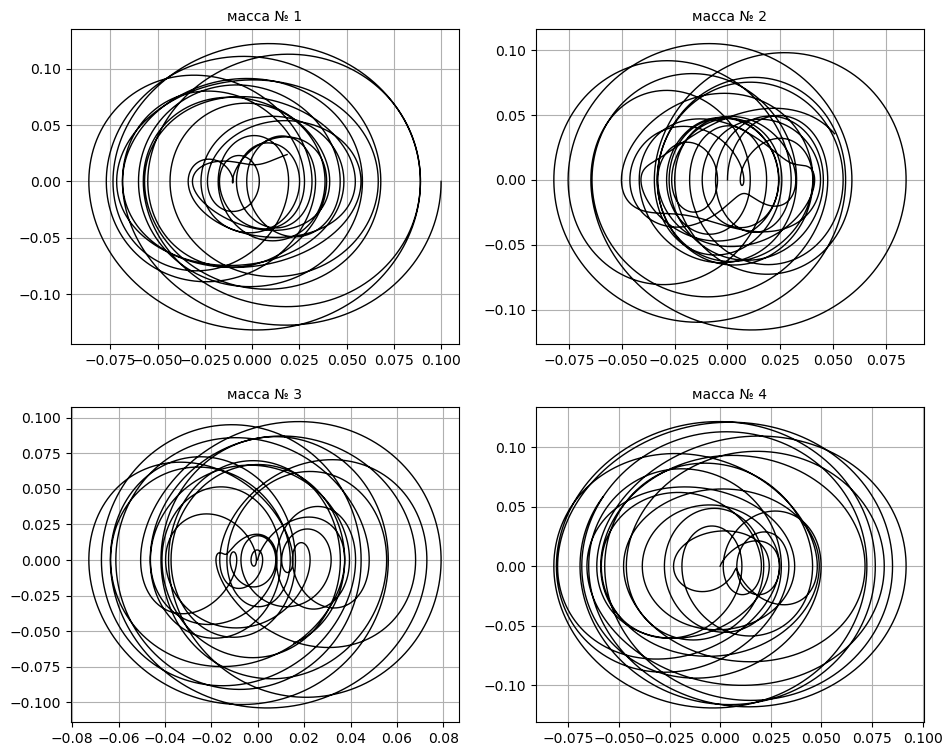

In [13]:
# Ячейка № 5

# визуализация фазовых траекторий масс
# масс колебательной системы от времени
fig = plt.figure(figsize=(11, 9))

# визуализация фазовой траектории
# массы № 1
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(X[0, :], Xv[0, :], "-k", lw=1)
ax1.grid(True)
ax1.set_title("масса № 1", fontsize=10)

# визуализация фазовой траектории
# массы № 2
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(X[1, :], Xv[1, :], "-k", lw=1)
ax2.grid(True)
ax2.set_title("масса № 2", fontsize=10)

# визуализация фазовой траектории
# массы № 3
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(X[2, :], Xv[2, :], "-k", lw=1)
ax3.grid(True)
ax3.set_title("масса № 3", fontsize=10)

# визуализация фазовой траектории
# массы № 4
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(X[3, :], Xv[3, :], "-k", lw=1)
ax4.grid(True)
ax4.set_title("масса № 4", fontsize=10)

plt.show()

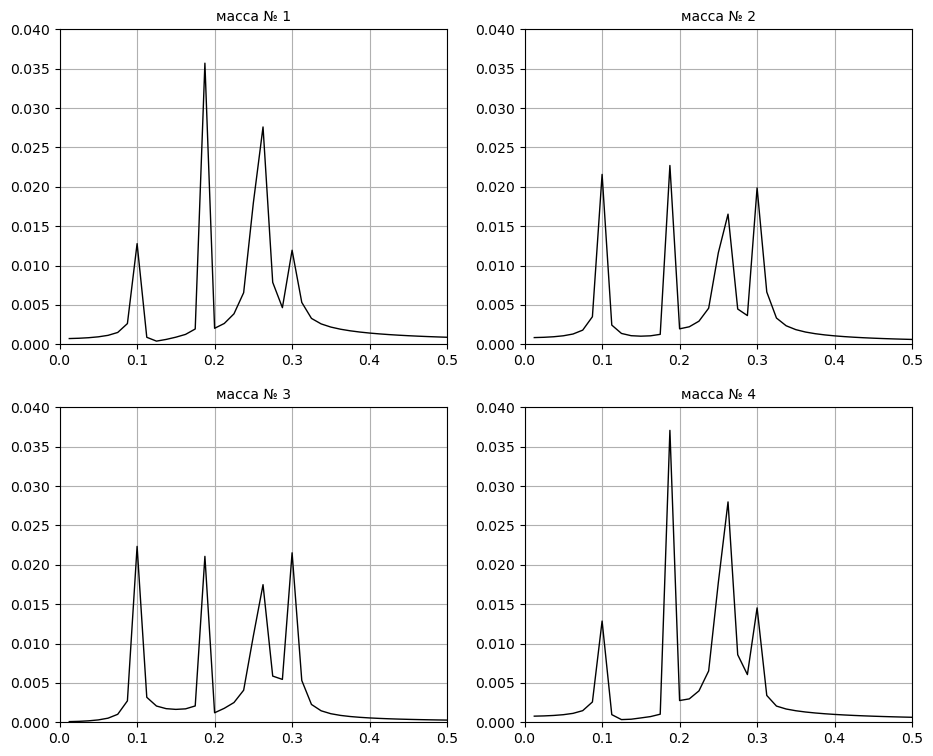

In [ ]:
# Ячейка № 6

# вычисление и визуализация спектров
# зависимостей смещений от положений
# равновесия масс колебательной системы от времени

# шаг временной сетки,
# в узлах которой вычислены значения
# анализируемого сигнала
dt = t[1] - t[0]

# вычисление значения комплекснозначных
# коэффициентов ряда Фурье
c1 = fft(X[0, :])
c2 = fft(X[1, :])
c3 = fft(X[2, :])
c4 = fft(X[3, :])

# вычисление значений
# частот спектральных гармоник
Freq = fftfreq(N1, dt)

# задание числа информативных
# спектральных гармоник
N2 = round(N1 / 2) - 1

# инициализация массивов, используемых
# для хранения значений  нормированных амплитуд
# информативных спектральных гармоник и
# соответствующих частот
c_R1 = np.zeros(N2)
c_R2 = np.zeros(N2)
c_R3 = np.zeros(N2)
c_R4 = np.zeros(N2)
Freq_R = np.zeros(N2)

# размещение в массивах Freq_R и c_R
# значений циклических частот
# информативных спектральных гармоник
# и соответствующих нормированных амплитуд
for i in range(N2):
    Freq_R[i] = Freq[i + 1]
    c_R1[i] = np.abs(2 * c1[i + 1]) / N1
    c_R2[i] = np.abs(2 * c2[i + 1]) / N1
    c_R3[i] = np.abs(2 * c3[i + 1]) / N1
    c_R4[i] = np.abs(2 * c4[i + 1]) / N1

# визуализация спектров зависимостей
# смещения от положения равновесия
# масс колебательной системы от времени
fig = plt.figure(figsize=(11, 9))

# визуализация спектра зависимости
# смещения от положения равновесия
# массы № 1
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(Freq_R, c_R1, "-k", lw=1)
ax1.set_xlim([0, 0.5])
ax1.set_ylim([0, 0.04])
ax1.grid(True)
ax1.set_title("масса № 1", fontsize=10)

# визуализация спектра зависимости
# смещения от положения равновесия
# массы № 2
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(Freq_R, c_R2, "-k", lw=1)
ax2.set_xlim([0, 0.5])
ax2.set_ylim([0, 0.04])
ax2.grid(True)
ax2.set_title("масса № 2", fontsize=10)


# визуализация спектра зависимости
# смещения от положения равновесия
# массы № 3
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(Freq_R, c_R3, "-k", lw=1)
ax3.set_xlim([0, 0.5])
ax3.set_ylim([0, 0.04])
ax3.grid(True)
ax3.set_title("масса № 3", fontsize=10)


# визуализация спектра зависимости
# смещения от положения равновесия
# массы № 4
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(Freq_R, c_R4, "-k", lw=1)
ax4.set_xlim([0, 0.5])
ax4.set_ylim([0, 0.04])
ax4.grid(True)
ax4.set_title("масса № 4", fontsize=10)

plt.show()

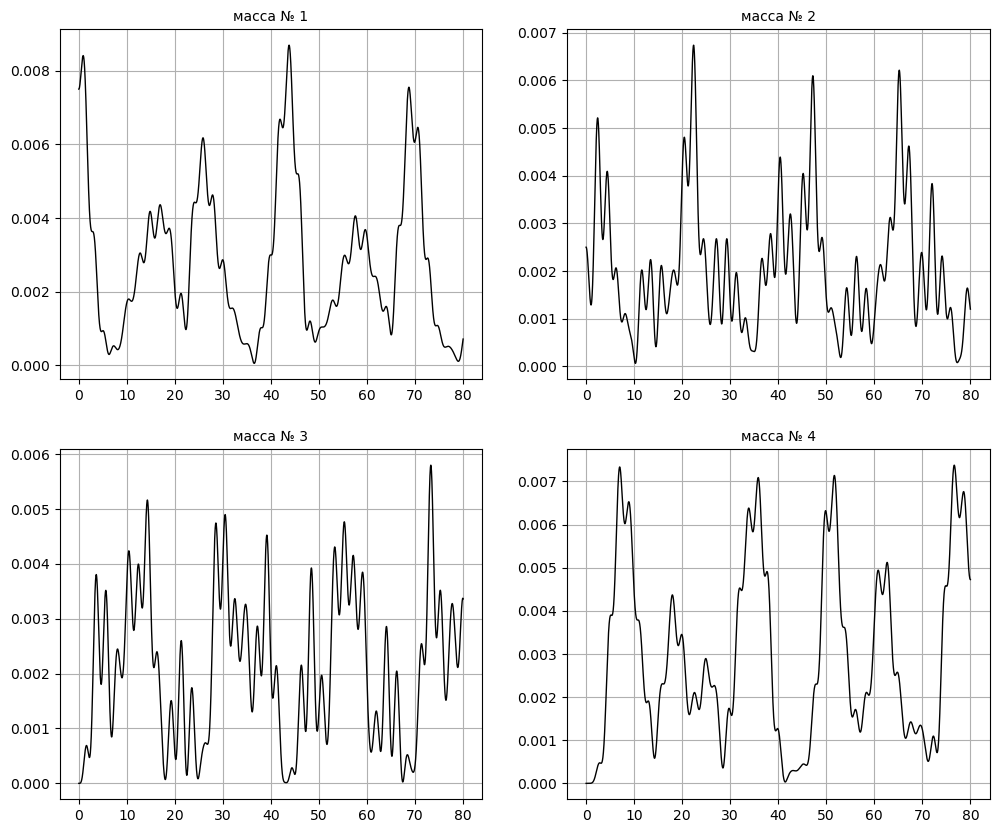

In [15]:
# Ячейка № 7

# вычисление и визуализация
# мгновенных значений энергий
# масс колебательной системы

# инициализация массива E,
# используемого для хранения
# мгновенных значений полной
# энергии масс колебательной системы
Np = len(t)
E = np.zeros([N, Np])

# создание массива y,
# используемого для размещения
# в его столбах последовательно
# мгновенных значений смещений
# масс колебательной системы от положений
# и мгновенных значений их скоростей
y = np.zeros([2 * N, Np])
for j in range(N):
    y[2 * j, :] = X[j, :]
    y[2 * j + 1, :] = Xv[j, :]

# вычисление мгновенных значений полной
# энергии масс колебательной системы
# в соответствие с (9.24)
for i in range(Np):
    for j in range(N):
        if j == 0:
            E[j, i] = (
                0.5 * m[j] * y[2 * j + 1, i] ** 2
                + 0.5 * k[j] * y[2 * j, i] ** 2
                + 0.25 * k[j + 1] * (y[2 * j, i] - y[2 * j + 2, i]) ** 2
            )
        if j == N - 1:
            E[j, i] = (
                0.5 * m[j] * y[2 * j + 1, i] ** 2
                + 0.5 * k[j + 1] * (y[2 * j, i]) ** 2
                + 0.25 * k[j] * (y[2 * j, i] - y[2 * j - 2, i]) ** 2
            )
        if (j > 0) & (j < N - 1):
            E[j, i] = (
                0.5 * m[j] * y[2 * j + 1, i] ** 2
                + 0.25 * k[j] * (y[2 * j, i] - y[2 * j - 2, i]) ** 2
                + 0.25 * k[j] * (y[2 * j, i] - y[2 * j + 2, i]) ** 2
            )

# визуализация зависимостей полной энергии
# масс колебательной системы от времени
# визуализация зависимостей смещений
# от положения равновесия
# масс колебательной системы от времени
fig = plt.figure(figsize=(12, 10))

# визуализация зависимости смещения
# от положения равновесия
# массы № 1 колебательной системы от времени
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(t[:], E[0, :], "-k", lw=1)
ax1.grid(True)
ax1.set_title("масса № 1", fontsize=10)


# визуализация зависимости смещения
# от положения равновесия
# массы № 2 колебательной системы от времени
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t, E[1, :], "-k", lw=1)
ax2.grid(True)
ax2.set_title("масса № 2", fontsize=10)

# визуализация зависимости смещения
# от положения равновесия
# массы № 3 колебательной системы от времени
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(t, E[2, :], "-k", lw=1)
ax3.grid(True)
ax3.set_title("масса № 3", fontsize=10)


# визуализация зависимости смещения
# от положения равновесия
# массы № 4 колебательной системы от времени
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(t, E[3, :], "-k", lw=1)
ax4.grid(True)
ax4.set_title("масса № 4", fontsize=10)

plt.show()

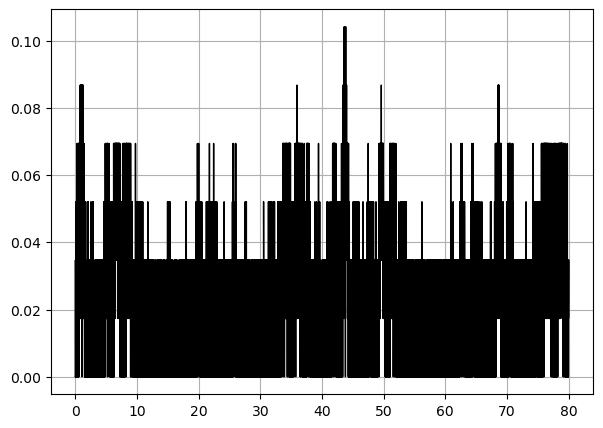

In [16]:
# Ячейка № 8

# визуализация зависимости
# мгновенных значений
# полной энергии колебательной системы от времени

# вычисление мгновенных значений
# полной энергии колебательной системы
# в соответствие с (9.24)
Efull = np.sum(E, axis=0)

# визуализация зависимости
# абсолютных значений разностей
# мгновенных значений энергии
# колебательной системы
# от начального значения энергии

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot()
ax.plot(t[:], abs(Efull[:] - Efull[0]) / Efull[0] * 10**14, "-k", lw=1)
ax.grid(True)

plt.show()